<a href="https://colab.research.google.com/github/Fedekasparian/Sistemas-inteligentes/blob/main/Notebook_AIyLLM_01_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Lineal con una neurona: Simulada vs Real

Esta notebook implementa, en primera instancia, una simulación de una neurona para resolver problemas de regresión lineal. Utilizamos un enfoque basado en el descenso de gradiente para entrenar los pesos y el bias de la neurona, minimizando el error cuadrático medio (MSE) entre las predicciones y los valores reales. A lo largo del entrenamiento, se actualizan los parámetros del modelo en función de la tasa de aprendizaje, y se visualiza el progreso del aprendizaje mediante un gráfico que muestra cómo el error disminuye en el tiempo. Para finalizar, comparamos las predicciones de la neurona con los valores reales para evaluar su desempeño.

Luego, se genera una neurona artificial real con TensorFlow y Keras.

Importamos las librerías necesarias:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Definimos dos atributos de entrada con dos variables y una salida esperada dada una relación lineal conocida:

In [ ]:
# Datos de entrenamiento como DataFrame
data = {
    "Variable 1": [1, 2, 3, 4, 5],
    "Variable 2": [2, 4, 6, 8, 10],
    "Salida Esperada": [9, 19, 29, 39, 49]  # Relación lineal conocida
}
df = pd.DataFrame(data)

In [ ]:
df

,Variable 1,Variable 2,Salida Esperada
0,1,2,9
1,2,4,19
2,3,6,29
3,4,8,39
4,5,10,49


Inicializamos el vector de pesos para las entradas, la tasa de aprendizaje y la cantidad de épocas (iteraciones):

In [ ]:
# Inicialización de pesos y bias
pesos = np.zeros(2)  # Dos pesos para dos entradas
bias = 0
tasa_aprendizaje = 0.01
epocas = 1000
epocas_aprendizaje_visualizacion = 50

Definimos una función para la predicción:

In [ ]:
# Función de predicción
def predecir(entrada, pesos, bias):
    return np.dot(entrada, pesos) + bias

Desarrollamos el entrenamiento en función de las épocas:

In [ ]:
# Lista para almacenar el MSE en cada punto
errores_mse = []

# Entrenamiento
for epoca in range(epocas):

    total_error = 0

    for i in range(len(df)):
        entrada = df.loc[i, ["Variable 1", "Variable 2"]].values
        salida_esperada = df.loc[i, "Salida Esperada"]

        # Predicción
        salida = predecir(entrada, pesos, bias)

        # Cálculo del error con RMSE (Error cuadrático medio)
        error = salida - salida_esperada
        total_error += error ** 2

        # Actualización de pesos y bias usando descenso de gradiente
        pesos -= tasa_aprendizaje * error * entrada
        bias -= tasa_aprendizaje * error

    # Mostrar el error total cada 100 épocas
    if (epoca + 1) % epocas_aprendizaje_visualizacion == 0:
        mse = total_error / len(df)
        print(f"Época {epoca + 1}, Error cuadrático medio: {mse}")
        errores_mse.append(mse)

Época 50, Error cuadrático medio: 0.24476780598380757
Época 100, Error cuadrático medio: 0.09090770723504335
Época 150, Error cuadrático medio: 0.033763473106749556
Época 200, Error cuadrático medio: 0.012539884140766996
Época 250, Error cuadrático medio: 0.004657361337403955
Época 300, Error cuadrático medio: 0.001729761964596387
Época 350, Error cuadrático medio: 0.0006424402655071535
Época 400, Error cuadrático medio: 0.00023860479256242713
Época 450, Error cuadrático medio: 8.861874027903872e-05
Época 500, Error cuadrático medio: 3.2913341950513385e-05
Época 550, Error cuadrático medio: 1.2224142150311087e-05
Época 600, Error cuadrático medio: 4.540093544296731e-06
Época 650, Error cuadrático medio: 1.6862082539253494e-06
Época 700, Error cuadrático medio: 6.262642493730944e-07
Época 750, Error cuadrático medio: 2.3259695777774478e-07
Época 800, Error cuadrático medio: 8.638740726750249e-08
Época 850, Error cuadrático medio: 3.208461626281367e-08
Época 900, Error cuadrático medio: 

Verificamos gráficamente como fue el proceso de aprendizaje:

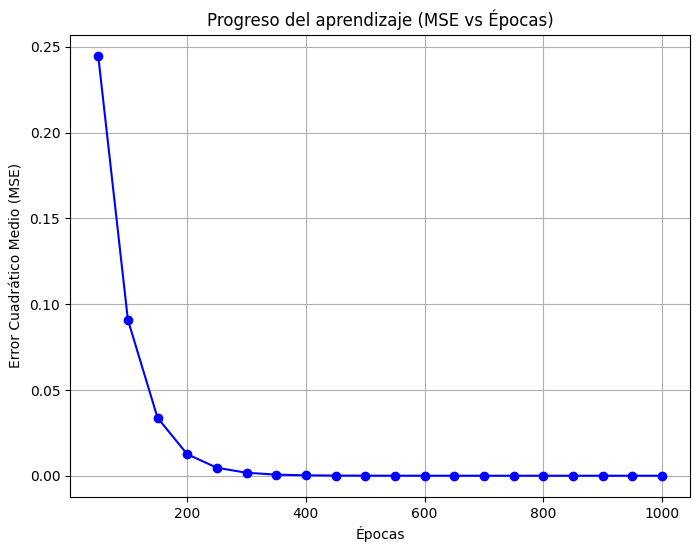

In [ ]:
# Visualización del aprendizaje
plt.figure(figsize=(8, 6))
plt.plot(range(50, epocas + 1, 50), errores_mse, marker='o', linestyle='-', color='blue')
plt.title("Progreso del aprendizaje (MSE vs Épocas)")
plt.xlabel("Épocas")
plt.ylabel("Error Cuadrático Medio (MSE)")
plt.grid()
plt.show()

Verificamos las predicciones finales post-entrenamiento:

In [ ]:
# Predicciones finales
df["Predicción"] = df.apply(lambda row: predecir([row["Variable 1"], row["Variable 2"]], pesos, bias), axis=1)

df

,Variable 1,Variable 2,Salida Esperada,Predicción
0,1,2,9,9.000069
1,2,4,19,19.000054
2,3,6,29,29.000038
3,4,8,39,39.000022
4,5,10,49,49.000007


In [ ]:
pesos
bias

-0.9999151626562921

Visualizamos los resultados:

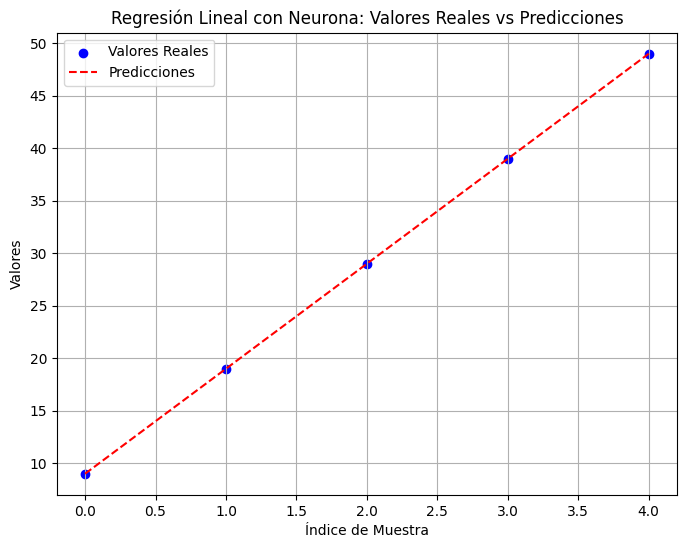

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(df)), df["Salida Esperada"], color='blue', label='Valores Reales')
plt.plot(range(len(df)), df["Predicción"], color='red', label='Predicciones', linestyle='--')
plt.title("Regresión Lineal con Neurona: Valores Reales vs Predicciones")
plt.xlabel("Índice de Muestra")
plt.ylabel("Valores")
plt.legend()
plt.grid()
plt.show()

Mostramos los pesos y el bias aprendido:

In [ ]:
print(f"Pesos finales: {pesos}")
print(f"Bias final: {bias}")

Pesos finales: [1.99999687 3.99999375]
Bias final: -0.9999151626562921


Por último, mostramos el dataframe con las predicciones:

In [ ]:
df

,Variable 1,Variable 2,Salida Esperada,Predicción
0,1,2,9,9.000069
1,2,4,19,19.000054
2,3,6,29,29.000038
3,4,8,39,39.000022
4,5,10,49,49.000007


## Funciones de activación para resolución de problemas no lineales

En el caso anterior, dado que se trató de una regresión lineal no necesitamos una función de activación, no obstante se definen (manualmente) las más comunes a continuación.

Definimos las funciones de activación clásicas manualmente (ReLU, paso binario, sigmoide, tangente, softplus):

In [ ]:
# Reimportar bibliotecas después del reinicio del estado
import numpy as np
import matplotlib.pyplot as plt

def activacion_relu(x):
    return np.maximum(0, x)

def activacion_paso_binario(x):
    return np.where(x >= 0, 1, 0)

def activacion_sigmoide(x):
    return 1 / (1 + np.exp(-x))

def activacion_tanh(x):
    return np.tanh(x)

def activacion_softplus(x):
    return np.log(1 + np.exp(x))

Aquí podemos parametrizar la función que querramos:

In [ ]:
funcion_activacion = activacion_relu

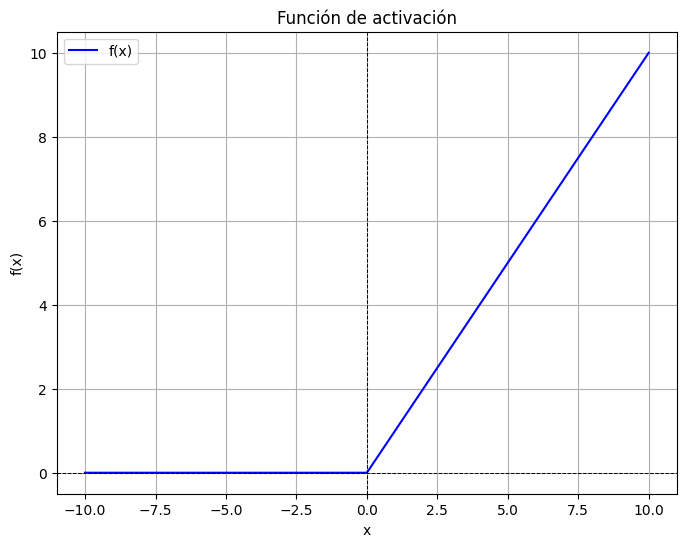

In [ ]:
# Generación de valores para la función ReLU
x = np.linspace(-10, 10, 500)
y = funcion_activacion(x)

# Crear el gráfico
plt.figure(figsize=(8, 6))
plt.plot(x, y, label="f(x)", color="blue")
plt.axhline(0, color="black", linestyle="--", linewidth=0.7)
plt.axvline(0, color="black", linestyle="--", linewidth=0.7)
plt.title("Función de activación")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.legend()
plt.show()

## Neurona artificial: Utilización de librerías específicas

A continuación se realiza la misma resolución con librerías específicas para redes neuronales.

Se importan las librerías necesarias:

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Datos de entrenamiento como DataFrame
data = {
    "Variable 1": [1, 2, 3, 4, 5],
    "Variable 2": [2, 4, 6, 8, 10],
    "Salida Esperada": [9, 19, 29, 39, 49]  # Relación lineal conocida
}

df = pd.DataFrame(data)

In [ ]:
# Entradas (X) y salidas (y)
X = df[["Variable 1", "Variable 2"]].values  # Matriz de entrada
y = df["Salida Esperada"].values  # Vector de salida

Se definen las funciones de activación de TensorFlow (paso binario no está incorporada):

In [ ]:
activaciones = {
    "Sigmoide": tf.nn.sigmoid,
    "Tangente Hiperbólica": tf.nn.tanh,
    "ReLU": tf.nn.relu,
    "Paso Binario": lambda x: tf.where(x >= 0, 1.0, 0.0)
}

Se definen las entradas, salidas y el modelo:

In [ ]:
# Definir el modelo de la red neuronal con entrada explícita
inputs = tf.keras.Input(shape=(2,))  # Definir las entradas (2 características)
outputs = tf.keras.layers.Dense(1, activation=None)(inputs)  # Una neurona sin activación
modelo = tf.keras.Model(inputs=inputs, outputs=outputs)  # Crear el modelo

Se realiza el entrenamiento:

In [ ]:
# Compilar el modelo
modelo.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
               loss='mse',  # Usamos MSE como función de pérdida
               metrics=['mse'])

# Entrenar el modelo
y_true = df["Salida Esperada"].values
historial = modelo.fit(X, y_true, epochs=1000, verbose=1)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step - loss: 426.1611 - mse: 426.1611
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 6.0933 - mse: 6.0933
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.3979 - mse: 0.3979
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.3184 - mse: 0.3184
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.3151 - mse: 0.3151
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.3129 - mse: 0.3129
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.3106 - mse: 0.3106
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.3084 - mse: 0.3084
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.3062 - mse: 0.3062
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.3040 - mse: 0.3040
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.3018 - mse: 0.3018
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.2997 - mse: 0.2997
Epoch 13/1000
1/1 ━━━━━━━━━━━━━

Realiza las predicciones:

In [ ]:
# Predicciones finales
y_pred = modelo.predict(X)

# Mostrar resultados
for entrada, prediccion, salida_real in zip(X, y_pred, y_true):
    print(f"Entrada: {entrada}, Predicción: {prediccion[0]:.2f}, Salida Real: {salida_real}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Entrada: [1 2], Predicción: 9.03, Salida Real: 9
Entrada: [2 4], Predicción: 19.02, Salida Real: 19
Entrada: [3 6], Predicción: 29.01, Salida Real: 29
Entrada: [4 8], Predicción: 39.00, Salida Real: 39
Entrada: [ 5 10], Predicción: 48.99, Salida Real: 49


Verificamos gráficamente como fue el proceso de aprendizaje:

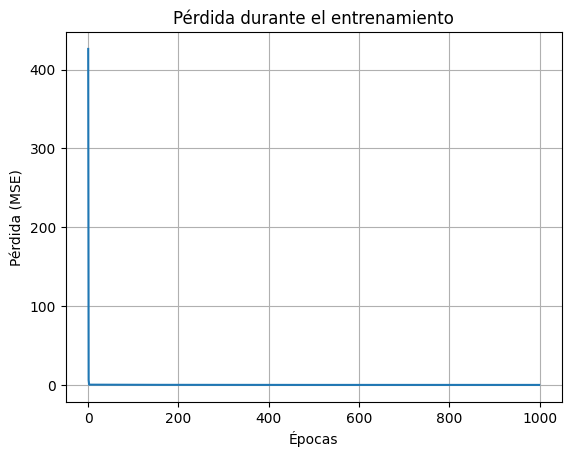

In [ ]:
# Graficar la pérdida
import matplotlib.pyplot as plt
plt.plot(historial.history['loss'])
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (MSE)")
plt.grid()
plt.show()

Se muestran los pesos y bias aprendidos:

In [ ]:
# Obtener los pesos y bias
pesos, bias = modelo.layers[1].get_weights()
print(f"Pesos aprendidos: {pesos.flatten()}")
print(f"Bias aprendido: {bias}")

Pesos aprendidos: [2.5174706 3.736219 ]
Bias aprendido: [-0.96311873]
